# PER with a Sparse Pauli–Lindblad Noise Model 

This notebook is a **theory-driven** introduction to **Probabilistic Error Reduction / Cancellation (PER/PEC)** using a **sparse Pauli–Lindblad noise model**, following:

E. van den Berg, Z. K. Minev, A. Kandala, K. Temme  
*Probabilistic error cancellation with sparse Pauli–Lindblad model* (arXiv:2201.09866)

We work through a **single, concrete example** end-to-end:
a 4-qubit VQE circuit (HVA for a 2×2 mixed-field Ising model), executed on a realistic noisy backend (Fake IBM snapshot).

---

The steps:

1. **Construct a target circuit** (VQE circuit from the previous notebook)
2. **Model noise as quantum channels** and motivate *layer-wise* noise
3. **Introduce the sparse Pauli–Lindblad model** (compact support, sparse topology)
4. **Learn the model** via tomography primitives:
   - Pauli twirling → diagonal Pauli channel
   - fidelity pairs → SPAM-robust decay
   - pair-breaking → split paired fidelities
5. **Apply PER** by sampling a partial inverse at several noise-strength values, and
6. **(Optional)** combine with ZNE to extrapolate to the zero-noise limit.

Throughout, we will explicitly state:
- what is assumed,
- what is measured,
- what is reconstructed,
- and where approximations enter.


## 1. Running example: a 4-qubit VQE circuit (HVA for MFIM)

To keep continuity, we reuse the same 4-qubit circuit family as in the previous notebook.
We will:
- build the MFIM Hamiltonian,
- build a 1-layer HVA ansatz,
- bind optimized parameters,
- and use this circuit as the target workload for tomography and PER.

The circuit itself is not the focus here — it is simply a realistic NISQ-style circuit with
single- and two-qubit gates and nontrivial depth.

In [1]:
import sys

sys.path.append('../..')
import numpy as np

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

from src.VQE_functions import optimize_energy, MFIM_Hamiltonian, build_hva_layers
from scipy.linalg import eigh
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, SparsePauliOp

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

hx = 1
hz = 1
J = -1

Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)
num_qubits = Hamiltonian.num_qubits
pauli_list = [p.to_label() for p in Hamiltonian.paulis]
hva_layers, params = build_hva_layers(topology=topology, num_layers=1)

backend = AerSimulator()

num_layers = 1
initial_params = [1,1,1]
bounds = [(-np.pi, np.pi)] * 3*num_layers

opt_params, energy, HelperInfo = optimize_energy(initial_params=initial_params, Hamiltonian=Hamiltonian, 
                                                 topology=topology, num_layers=num_layers, backend=backend, 
                                                 mode="measurement",bounds = bounds, shots=1024)

values = {p: v for p, v in zip(params, opt_params)}
qc_bound = hva_layers.assign_parameters(values)

print(qc_bound.draw(fold=-1))

exact_energy = np.min(eigh(Hamiltonian.to_matrix(), eigvals_only=True))

psi = Statevector.from_instruction(qc_bound)
expectation_values = []
for pauli_str in pauli_list:
    op = SparsePauliOp.from_list([(pauli_str, 1.0)])
    expval = np.real(psi.expectation_value(op))
    expectation_values.append(expval)

print("Measured energy: ",energy)
print("Relative error: ", np.abs(energy - exact_energy) / np.abs(exact_energy) *100, "%")
print("Initial parameters: ",initial_params)
print("Optimal parameters: ", opt_params)

     ┌───┐┌─────────────┐┌────────────┐                                                                   
q_0: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├──■──────────────────■────■────────────────────────────────■───────
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌────────────┐┌─┴─┐  │                                │       
q_1: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├┤ X ├┤ Rz(1.2974) ├┤ X ├──┼────────■───────────────────────┼────■──
     ├───┤├─────────────┤├────────────┤└───┘└────────────┘└───┘  │      ┌─┴─┐     ┌────────────┐  │  ┌─┴─┐
q_2: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├──■──────────────────■────┼──────┤ X ├─────┤ Rz(1.2974) ├──┼──┤ X ├
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌────────────┐┌─┴─┐┌─┴─┐┌───┴───┴────┐└────────────┘┌─┴─┐└───┘
q_3: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├┤ X ├┤ Rz(1.2974) ├┤ X ├┤ X ├┤ Rz(1.2974) ├──────────────┤ X ├─────
     └───┘└─────────────┘└────────────┘└───┘└────────────┘└───┘└───┘└────────────┘              └───┘     
Measured energy:  -8.59375
Relative e


We will use this fixed circuit `qc` as the object of study.

The quantity of interest in VQE is the energy

$$
E = \langle H \rangle = \sum_{m} h_m \langle P_m \rangle
$$

i.e., a weighted sum of Pauli expectation values.

In an ideal setting, these expectation values are estimated from repeated measurements (“shots”).
On real hardware, the estimator becomes **biased by noise**, and PER aims to remove this bias
without changing the hardware.

## 2. Noise model: channels acting on density matrices

A quantum circuit ideally implements a unitary channel
$$
\mathcal{U}(\rho) = U \rho U^\dagger.
$$

On real hardware, each operation is followed (or accompanied) by noise.
A standard abstraction is to describe noise as a **completely positive trace-preserving (CPTP)** map
(a quantum channel) $\Lambda$, such that the implemented operation becomes

$$
\rho \mapsto \Lambda\!\left(\mathcal{U}(\rho)\right).
$$

If a circuit consists of gates $U_1, U_2, \dots, U_L$, the noisy circuit implements a composition
of alternating ideal gates and noise channels:

$$
\rho_{\text{out}}
= \Lambda_L \circ \mathcal{U}_L \circ \cdots \circ \Lambda_2 \circ \mathcal{U}_2 \circ \Lambda_1 \circ \mathcal{U}_1(\rho_{\text{in}}).
$$

In full generality, each $\Lambda_\ell$ could act nontrivially on **all qubits simultaneously**.
This is mathematically allowed but physically inconvenient:
the number of degrees of freedom of a general channel scales exponentially with system size.

To make progress, we exploit physical structure:
**NISQ circuits are built from 1- and 2-qubit gates**, and in current devices the dominant
errors typically come from **two-qubit entangling gates**.
This motivates a *layered* view of circuits.


## 3. Decompose the circuit into layers

Hardware-native compilation typically yields circuits built from:
- single-qubit rotations and
- entangling two-qubit gates.

Two key empirical facts motivate layer-wise modeling:

1. **Entangling gates are the main error source.**  
   On many superconducting devices, two-qubit gate error rates are commonly an order of magnitude
   larger than single-qubit gate errors (and often dominate the total infidelity).

2. **Two-qubit gates act locally along the device coupling graph.**  
   Qubits only interact if there is a physical link; routing through SWAPs creates additional
   noisy gates and changes the effective noise.

Because of this, we partition a compiled circuit into **layers** of the form:

- (A) parallel single-qubit gates, followed by
- (B) a set of two-qubit Clifford gates with **disjoint supports** (no qubit participates twice).

We then associate each layer $\ell$ with its own noise channel $\Lambda_\ell$ and write the total
noise as a concatenation of layer-wise channels:

$$
\Lambda_{\text{total}} \approx \Lambda_L \circ \Lambda_{L-1} \circ \cdots \circ \Lambda_1.
$$

This does *not* claim noise is truly independent between layers — it is an approximation that
becomes useful once combined with the next assumption: **sparsity**.


In [ ]:
def circuit_to_layers(qc):
    """
    Split a circuit into benchmark layers of the form

        (any single-qubit gates)
        + (a disjoint set of two-qubit gates)

    A layer is kept only if it contains at least one two-qubit gate.
    """

    layers = []

    # remaining instructions (ignore measurements)
    inst_list = [ci for ci in qc.data if ci.operation.name != "measure"]

    # build layers until nothing is left
    while inst_list:

        circ = qc.copy_empty_like()
        layer_qubits = set()   # qubits occupied by 2Q gates in this layer

        # greedy sweep over remaining instructions
        for inst in inst_list.copy():

            support = set(inst.qubits)
            weight = len(inst.qubits)

            # add instruction if it does not overlap with existing 2Q supports
            if not layer_qubits.intersection(support):
                circ.append(inst.operation, inst.qubits, inst.clbits)
                inst_list.remove(inst)

                # 2Q gates block their qubits for further 2Q gates
                if weight == 2:
                    layer_qubits |= support

        # keep only layers that actually contain a 2Q gate
        for inst in circ.data:
            if len(inst.qubits) == 2:
                layers.append(circ)
                break

    return layers


def layers_with_barriers(qc, layers):
    """
    Reconstruct full circuit with barriers between benchmark layers.
    Each barrier is labeled with the layer index.
    """

    out = qc.copy_empty_like()

    for i, layer in enumerate(layers):
        out.compose(layer, inplace=True)

        # labeled barrier after each layer
        out.barrier(label=f"Layer {i}")

    return out

layers = circuit_to_layers(qc_bound)

qc_layers = layers_with_barriers(qc_bound, layers)

print(qc_layers.draw(fold=-1))


     ┌───┐┌─────────────┐┌────────────┐      Layer 0                     Layer 1            Layer 2                          Layer 3 
q_0: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├──■──────░────────────────────■──────░──────■───────────░────────────────────■───────────░────
     ├───┤├─────────────┤├────────────┤┌─┴─┐    ░    ┌────────────┐┌─┴─┐    ░      │           ░                    │           ░    
q_1: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├┤ X ├────░────┤ Rz(1.2974) ├┤ X ├────░──────┼────■──────░────────────────────┼────■──────░────
     ├───┤├─────────────┤├────────────┤└───┘    ░    └────────────┘└───┘    ░      │  ┌─┴─┐    ░    ┌────────────┐  │  ┌─┴─┐    ░    
q_2: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├──■──────░────────────────────■──────░──────┼──┤ X ├────░────┤ Rz(1.2974) ├──┼──┤ X ├────░────
     ├───┤├─────────────┤├────────────┤┌─┴─┐    ░    ┌────────────┐┌─┴─┐    ░    ┌─┴─┐└───┘    ░    ├────────────┤┌─┴─┐└───┘    ░    
q_3: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├┤ X ├────░────┤ Rz(1.29

### Pauli twirling → Pauli-diagonal effective noise

Pauli operators form a complete operator basis. For $n$ qubits, any density matrix can be written as
$$
\rho = \frac{1}{2^n}\sum_a r_a P_a,
\qquad P_a \in \{I,X,Y,Z\}^{\otimes n}.
$$
Since quantum channels are linear maps, their action on arbitrary states is fully determined
by how they act on the Pauli basis operators $P_a$.

A general noise channel acts as
$$
\Lambda(P_b) = \sum_a T_\Lambda[a,b]\,P_a,
$$
where $T_\Lambda$ is the Pauli transfer matrix. In general, this matrix is dense, meaning that
a single Pauli operator is mapped to a linear combination of many Pauli operators.

Pauli twirling removes this Pauli mixing by symmetrization. The twirled channel is defined as
$$
\Lambda(\cdot)
=
\frac{1}{|\mathcal P|}
\sum_{Q \in \mathcal P}
Q^\dagger\,\widetilde{\Lambda}\!\left(Q(\cdot)Q^\dagger\right)\,Q,
$$
where $\mathcal P$ is the Pauli group.
Averaging over all Pauli conjugations projects the channel onto the subspace that is invariant
under Pauli conjugation. As a result, the Pauli transfer matrix becomes diagonal and each Pauli
operator becomes an eigen-operator of the channel:
$$
\widetilde{\Lambda}_\ell(P_a) = f_{\ell,a}\,P_a.
$$
The coefficients
$$
f_{\ell,a}
=
2^{-n}\operatorname{Tr}\!\bigl(P_a\,\widetilde{\Lambda}_\ell(P_a)\bigr)
$$
are called **Pauli fidelities**.

---
#### Monte Carlo implementation

The exact average over all $4^n$ Pauli operators is not evaluated explicitly. Instead,
Pauli twirling is implemented via Monte Carlo sampling:

1. Sample a Pauli operator
   $$
   P = P_1 \otimes \cdots \otimes P_n,
   \qquad P_i \in \{I,X,Y,Z\},
   $$
   uniformly at random. Equivalently, each qubit independently chooses $I,X,Y,$ or $Z$
   with probability $1/4$.

2. Insert $P$ before the noisy layer.

3. Insert $P^\dagger$ after the noisy layer (or, if the layer is Clifford, insert the
   conjugated Pauli pushed through the Clifford).

4. Repeat this procedure for many circuit executions and average measurement outcomes.

In expectation, this Monte Carlo procedure converges to the exact Pauli-twirled channel.

---



In [ ]:
import random
from qiskit.quantum_info import Pauli

PAULIS = ["I", "X", "Y", "Z"]

def apply_pauli_string(qc, pauli_string):
    """
    Apply a Pauli string given as ['I','X','Y','Z',...] to a circuit.
    """
    for q, p in enumerate(pauli_string[::-1]):
        if p == "X":
            qc.x(q)
        elif p == "Y":
            qc.y(q)
        elif p == "Z":
            qc.z(q)

    return qc

def extract_two_qubit_structure(layer):
    """
    Return a list of (gate, q1, q2) for all 2Q gates in the layer,
    where gate is the actual Instruction (e.g. CXGate, CZGate).
    """
    structure = []

    for inst in layer.data:
        if len(inst.qubits) == 2:
            q1 = inst.qubits[0]._index
            q2 = inst.qubits[1]._index
            structure.append((inst.operation, q1, q2))

    return structure

def conjugate_pauli_2q(pauli_string, layer):
    p = Pauli(pauli_string)
    
    for inst in layer.data:
        if len(inst.qubits) == 2:
            qargs = [q._index for q in inst.qubits]
            p = p.evolve(inst.operation, qargs=qargs, frame="s")
            
    return p.to_label().lstrip("+-i")


def pauli_twirl_layers(qc, layers, num_samples=1):
    """
    Perform Pauli twirling around the 2Q Clifford part of each layer.

    Returns:
        {"layer0": [qc_sample_0, qc_sample_1, ...], ...}
    """
    num_qubits = qc.num_qubits
    twirled = {}

    for ell, layer in enumerate(layers):
        layer_samples = []

        for _ in range(num_samples):
            qc_twirl = qc.copy_empty_like()

            # --- (A) single-qubit gates FIRST (ideal dynamics)
            for inst in layer.data:
                if len(inst.qubits) == 1:
                    qc_twirl.append(inst.operation, inst.qubits)

            qc_twirl.barrier(label=f"1Q layer {ell}")

            # --- (B) sample Pauli
            P = "".join([random.choice(PAULIS) for _ in range(num_qubits)])

            qc_twirl = apply_pauli_string(qc_twirl, P)
            qc_twirl.barrier(label=f"Twirl before 2Q layer {ell}")

            # --- (C) apply only 2Q Cliffords
            for inst in layer.data:
                if len(inst.qubits) == 2:
                    qc_twirl.append(inst.operation, inst.qubits)

            qc_twirl.barrier(label=f"2Q layer {ell}")

            # --- (D) apply conjugated Pauli
            P_conj = conjugate_pauli_2q(P, layer)
            qc_twirl = apply_pauli_string(qc_twirl, P_conj)
            qc_twirl.barrier(label=f"Twirl after 2Q layer {ell}")

            layer_samples.append(qc_twirl)

        twirled[f"layer{ell}"] = layer_samples

    return twirled


N=100
twirled_layers = pauli_twirl_layers(qc_bound, layers, num_samples=N)

print("One twirled sample:")
print(twirled_layers["layer0"][0].draw(fold=-1))

One twirled sample:
     ┌───┐┌─────────────┐┌────────────┐ 1Q layer 0 ┌───┐ Twirl before 2Q ...       2Q layer 0 ┌───┐ Twirl after 2Q l... 
q_0: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├─────░──────┤ Y ├──────────░────────────■───────░──────┤ Y ├──────────░──────────
     ├───┤├─────────────┤├────────────┤     ░      ├───┤          ░          ┌─┴─┐     ░      └───┘          ░          
q_1: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├─────░──────┤ X ├──────────░──────────┤ X ├─────░─────────────────────░──────────
     ├───┤├─────────────┤├────────────┤     ░      └───┘          ░          └───┘     ░                     ░          
q_2: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├─────░─────────────────────░────────────■───────░─────────────────────░──────────
     ├───┤├─────────────┤├────────────┤     ░      ┌───┐          ░          ┌─┴─┐     ░      ┌───┐          ░          
q_3: ┤ H ├┤ Rz(-1.4348) ├┤ Rx(1.5078) ├─────░──────┤ X ├──────────░──────────┤ X ├─────░──────┤ X ├──────────░──────────
     └───┘└─

## Sanity Check

For all the circuit instances the expectationvalue should be the same, we check that with a Statevectorsimulation.

In [4]:
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit

qc_twirl = QuantumCircuit(qc_bound.num_qubits)

for ell, layer in enumerate(layers):
    twirled_layer = twirled_layers[f"layer{ell}"][0]
    qc_twirl.compose(twirled_layer, inplace=True)

psi_ref = Statevector.from_instruction(qc_bound)
psi_twirl = Statevector.from_instruction(qc_twirl)

print(f"original circuit: E = {np.real(psi_ref.expectation_value(Hamiltonian))}")
print(f"twirled circuit: E = {np.real(psi_twirl.expectation_value(Hamiltonian))}")

original circuit: E = -8.446377625973216
twirled circuit: E = -8.446377625973216


## Pauli–Lindblad noise model

### From discrete channels to generators

Instead of parameterizing $\Lambda$ directly, it is often more convenient to
parameterize a **generator** $\mathcal{L}$ and define the channel as

$$
\Lambda = e^{\mathcal{L}} .
$$

This form is familiar from open quantum systems:
if $\mathcal{L}$ generates a Markovian master equation

$$
\frac{d\rho(t)}{dt} = \mathcal{L}(\rho(t)),
$$

then the solution after a time step $\Delta t$ is

$$
\rho(\Delta t) = e^{\Delta t \mathcal{L}}(\rho(0)).
$$

In the circuit setting, we interpret **one circuit layer** as one fixed time step.
Writing the noise per layer as an exponential of a generator ensures that the resulting
map is **completely positive and trace preserving**.

---

### Lindblad generators built from Paulis

After twirling, it is natural to choose a generator that is itself diagonal in the
Pauli basis. This is achieved by using **Pauli jump operators**.

For a Pauli operator $P_k$, define the superoperator

$$
\mathcal{P}_k(\rho) = P_k \rho P_k .
$$

The Pauli–Lindblad generator is defined as

$$
\mathcal{L}
=
\sum_k \lambda_k \bigl( \mathcal{P}_k - \mathcal{I} \bigr),
\qquad
\lambda_k \ge 0 .
$$

Each term has a clear interpretation:

- $\mathcal{P}_k$ flips the state by conjugation with $P_k$.
- Subtracting the identity $\mathcal{I}$ ensures trace preservation.
- The coefficient $\lambda_k$ sets the **rate** at which this Pauli error occurs.

This is a special case of the general Lindblad form, with Hermitian jump operators
proportional to Pauli matrices.

---

### Why this generator is Pauli-diagonal

Consider how $\mathcal{L}$ acts on a Pauli operator $P_a$.

Conjugation by another Pauli either preserves or flips the sign:

- If $P_k$ commutes with $P_a$, then $P_k P_a P_k = P_a$.
- If $P_k$ anticommutes with $P_a$, then $P_k P_a P_k = -P_a$.

Therefore,

$$
(\mathcal{P}_k - \mathcal{I})(P_a)
=
\begin{cases}
0, & [P_k, P_a] = 0, \\
-2 P_a, & \{P_k, P_a\} = 0 .
\end{cases}
$$

Summing over all $k$ gives

$$
\mathcal{L}(P_a)
=
-2
\Bigl(
\sum_{k:\, \{P_k,P_a\}=0} \lambda_k
\Bigr)
P_a .
$$

Thus **every Pauli is an eigen-operator** of $\mathcal{L}$.

Exponentiating yields the channel action

$$
\Lambda(P_a)
=
\exp\!\Bigl(
-2 \sum_{k:\, \{P_k,P_a\}=0} \lambda_k
\Bigr)
P_a .
$$

This shows explicitly that the Pauli–Lindblad channel is Pauli-diagonal, and it
connects the generator parameters $\lambda_k$ directly to the Pauli fidelities.

---

### Relation to Pauli fidelities

Comparing with the twirled form

$$
\Lambda(P_a) = f_a P_a ,
$$

we identify

$$
f_a
=
\exp\!\Bigl(
-2 \sum_{k:\, \{P_k,P_a\}=0} \lambda_k
\Bigr).
$$

Hence:
- Pauli fidelities are **not independent parameters**.
- They are constrained by a small set of non-negative rates $\lambda_k$.
- This guarantees $0 < f_a \le 1$ automatically.

### Choosing the model terms (sparsity assumption)

In practice, we do not include all Paulis in the generator.
Instead, we restrict to terms that reflect the hardware noise structure:

- **Weight-1 terms**: $X_i, Y_i, Z_i$ on each qubit, capturing local decoherence and control errors.
- **Weight-2 terms**: $P_i \otimes P_j$ on qubit pairs $(i,j)$ that participate in entangling gates,
  capturing correlated errors introduced by two-qubit operations.

This choice defines the **Pauli–Lindblad model space**. The corresponding rates
$\{\lambda_k\}$ are the parameters to be learned experimentally.


In [5]:
from itertools import product, cycle, permutations

PAULIS_1Q = ["X", "Y", "Z"]
PAULIS_2Q = list(product(["X", "Y", "Z"], repeat=2))

def build_pauli_lindblad_terms(qc, backend, phys_qubits=None):
    """
    Build sparse Pauli–Lindblad model terms using BackendV2 target connectivity.
    """
    num_qubits = qc.num_qubits
    mapping = {phys: log for log, phys in enumerate(phys_qubits)}

    M = np.array(backend.coupling_map.get_edges())
    mask = np.isin(M[:, 0], phys_qubits) & np.isin(M[:, 1], phys_qubits)
    used_edges = np.unique(np.sort(M[mask], axis=1), axis=0)

    terms = []

    # --- 1Q terms ---
    for q in phys_qubits:
        q = mapping[q]
        for p in PAULIS_1Q:
            label = ["I"] * num_qubits
            label[q] = p
            terms.append("".join(label)[::-1])

    # --- 2Q terms ---
    for (q1, q2) in used_edges:
        q1 = mapping[q1]
        q2 = mapping[q2]
        for p1, p2 in PAULIS_2Q:
            label = ["I"] * num_qubits
            label[num_qubits - 1 - q1] = p1
            label[num_qubits - 1 - q2] = p2
            terms.append("".join(label)[::-1])

    return terms

from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

fake_backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(fake_backend)
backend_noisy = AerSimulator(noise_model=noise_model)

phys_qubits = [3,4,5,15]

model_terms = build_pauli_lindblad_terms(qc_bound, fake_backend, phys_qubits)
print(f"Number of model terms: {len(model_terms)}")

Number of model terms: 39


In the next step we group the qubit wise commuting model terms for efficient measurement.

In [6]:
NUM_BASES = 9

bases = [['I']*num_qubits for i in range(NUM_BASES)]
connectivity = fake_backend.coupling_map.graph.subgraph(phys_qubits)

for vertex in range(num_qubits):
    #copied from Fig. S3 in van den Berg
    orderings = {"XXXYYYZZZ":"XYZXYZXYZ",
                        "XXXYYZZZY":"XYZXYZXYZ",
                        "XXYYYZZZX":"XYZXYZXYZ",
                        "XXZYYZXYZ":"XYZXZYZYX",
                        "XYZXYZXYZ":"XYZZXYYZX"}
    
    children = connectivity.neighbors(vertex)
    predecessors = [c for c in children if c < vertex]

    match len(predecessors):
        #trivial if no predecessors
        case 0:
            cycp = cycle("XYZ")
            for i,_ in enumerate(bases):
                bases[i][vertex] = next(cycp)
        #Choose p1:"XXXYYYZZZ" and p2:"XYZXYZXYZ" if one predecessor
        case 1:
            pred, = predecessors
            #store permutation of indices so that predecessor has X,X,X,Y,Y,Y,Z,Z,Z
            _,bases = list(zip(*sorted(zip([p[pred] for p in bases], bases))))
            cycp = cycle("XYZ")
            for i,_ in enumerate(bases):
                bases[i][vertex] = next(cycp)
        case 2:
            pred0,pred1 = predecessors
            _,bases = list(zip(*sorted(zip([p[pred0] for p in bases], bases))))
            #list out string with permuted values of predecessor 2
            substr = [p[pred0] for p in bases]
            #match predecessor two with a permutation of example_orderings
            reordering = ""
            for perm in permutations("XYZ"):
                substr = "".join(["XYZ"[perm.index(p)] for p in substr])
                if substr in orderings:
                    current = orderings[substr] 
                    for i,p in enumerate(current):
                        bases[i][vertex] = p
                    break
        case _: #processor needs to have connectivity so that there are <= 2 predecessors
            raise Exception("Three or more predecessors encountered")

print("Measurement bases:", ["".join(b) for b in bases])
bases = [Pauli("".join(string[::-1])) for string in bases]

Measurement bases: ['XXXX', 'YXYY', 'ZXZZ', 'XYXX', 'YYYY', 'ZYZZ', 'XZXX', 'YZYY', 'ZZZZ']


## Simultaneous single measurements and degeneracy lifting

At first sight, estimating the fidelity of a Pauli–Lindblad model term seems
straightforward. After Pauli twirling, each Pauli operator $P$ is an
eigen-operator of the noise channel, and one might expect that its fidelity
can be extracted by repeatedly running the circuit and measuring the decay
of $\langle P \rangle$.

This intuition is *only correct if the noise channel acts in isolation*.
In practice, each noisy layer has the form
$$
\tilde{\mathcal U} = \mathcal U \circ \Lambda ,
$$
where $\mathcal U(\rho) = U\rho U^\dagger$ is a Clifford layer (typically a
collection of CX or CZ gates) and $\Lambda$ is the Pauli-twirled noise.

---

### Why the naive decay picture fails

To see the problem, switch to the Heisenberg picture.
Suppose we attempt to track the decay of a Pauli operator $P$.
After one layer we have
$$
P \;\xleftarrow{\;\mathcal U\;}\; U^\dagger P U .
$$
Because $U$ is a Clifford operator, $U^\dagger P U$ is *another* Pauli.
On the next repetition, the noise acts on this new Pauli instead of the
original one.

As a result, the Pauli operator whose expectation value we are tracking
**changes from repetition to repetition**.

---

### Example: CZ-induced degeneracy

Consider a CZ gate acting on qubits $i$ and $j$. One has
$$
\mathrm{CZ}^\dagger (I_i \otimes X_j)\,\mathrm{CZ}
=
Z_i \otimes X_j .
$$
If we try to measure the decay of $I_i X_j$, then successive repetitions
of the noisy CZ layer produce the sequence
$$
I_i X_j \;\longleftrightarrow\; Z_i X_j \;\longleftrightarrow\; I_i X_j \;\cdots
$$

After $2m$ repetitions, the measured expectation value behaves as
$$
\langle I_i X_j \rangle_{2m}
=
\alpha \,(f_{I_i X_j} f_{Z_i X_j})^{m}.
$$
Only the *product* of fidelities appears. The individual fidelities
$f_{I_i X_j}$ and $f_{Z_i X_j}$ are never observed separately.

---

### Degeneracy in the linear inversion problem

In the Pauli–Lindblad model, fidelities are related to Lindblad rates
$\lambda$ via
$$
-\tfrac{1}{2}\log f = M \lambda ,
$$
where the matrix $M$ is determined by Pauli commutation relations.

When Clifford conjugation forces two Pauli operators to always appear as a
pair (as in the example above), the corresponding columns of $M$ are
identical. This creates a **degeneracy**:
the matrix $M$ loses rank and cannot be inverted.

This degeneracy arises whenever:
- a Pauli and its Clifford conjugate are distinct, and
- both are included as separate terms in the sparse model.

---

### Degeneracy lifting via additional measurement bases

The degeneracy is not fundamental; it can be lifted by performing a small number of additional measurements in
different single-qubit bases.

Key observations:
- Pauli terms acting on *disjoint gates* do not interfere and can be measured
  simultaneously.
- For a two-qubit Clifford gate, two single-qubit Pauli operators are
  stabilized by the Clifford and do not mix.
- The remaining four single-qubit Pauli terms require additional basis
  choices to separate their contributions.
- In addition, two weight-two Pauli terms must be measured to fully lift the
  degeneracy.

Altogether, **six measurement bases per gate** suffice to uniquely identify
all model parameters.


In [7]:
def get_expectation(pauli, counts):
    """
    Expectation value of a Pauli string from Z-basis counts after the proper basis rotation.
    Assumption: X/Y were rotated to Z before measurement (H or Sdg+H).

    Qiskit convention:
    - Pauli label: left = qubit n-1, right = qubit 0
    - Bitstring:   left = qubit n-1, right = qubit 0
    """
    label = pauli.to_label() if hasattr(pauli, "to_label") else str(pauli)
    shots = sum(counts.values())
    if shots == 0:
        return 0.0

    exp = 0.0
    for bitstring, cnt in counts.items():
        parity = 0
        for pos, p in enumerate(label):         # pos=0 ↔ qubit n-1 … pos=n-1 ↔ qubit 0
            if p != 'I':
                parity ^= (bitstring[pos] == '1')
        exp += (1.0 if parity == 0 else -1.0) * cnt

    return exp / shots

def pauli_exp_dict_local(groups, counts):
    pauli_expectations = []

    for idx, group in enumerate(groups):
        group_expectation = {}
        for pauli_str in group:
            pauli = Pauli(pauli_str)
            exp_val = get_expectation(pauli=pauli, counts=counts[idx])
            group_expectation[pauli_str] = exp_val
        pauli_expectations.append(group_expectation)

    merged = {}
    for d in pauli_expectations:
        merged.update(d)
    return merged

from qiskit.quantum_info import Pauli
import networkx as nx

def locally_commutable(p1, p2):
    """
    Check whether two Pauli strings are locally measurable:
    no qubit has different non-identity Paulis (e.g., X and Y) at the same time.
    """
    for a, b in zip(p1, p2):
        if a == 'I' or b == 'I':
            continue
        if a != b:
            return False  # different non-I terms → not locally measurable at once
    return True

def group_paulis(pauli_strings):

    # ===== Normal (non-trivial) case with graph coloring =====
    G = nx.Graph()
    G.add_nodes_from(range(len(pauli_strings)))

    # Edge if they are NOT jointly measurable (conflict graph)
    for i in range(len(pauli_strings)):
        for j in range(i + 1, len(pauli_strings)):
            if not locally_commutable(pauli_strings[i], pauli_strings[j]):
                G.add_edge(i, j)

    # Graph coloring
    coloring = nx.coloring.greedy_color(G, strategy="largest_first")

    # Group by colors
    groups = {}
    for idx, color in coloring.items():
        groups.setdefault(color, []).append(pauli_strings[idx])

    return list(groups.values())

def determine_measurement_bases(pauli_groups: list[list[str]]) -> list[list[str]]:
    """
    Determine measurement bases for a list of Pauli groups.
    Returns: list of bases (each a list of 'X', 'Y', 'Z', 'I').
    """
    bases = []
    for group in pauli_groups:
        num_qubits = len(group[0])
        basis = ['Z'] * num_qubits  # Default: measure in Z

        for qubit in range(num_qubits):
            paulis_on_qubit = set(
                p[num_qubits - 1 - qubit] for p in group if p[num_qubits - 1 - qubit] != 'I'
            )

            if not paulis_on_qubit:
                basis[qubit] = 'I'
            elif paulis_on_qubit == {'Z'}:
                basis[qubit] = 'Z'
            elif paulis_on_qubit == {'X'}:
                basis[qubit] = 'X'
            elif paulis_on_qubit == {'Y'}:
                basis[qubit] = 'Y'
            else:
                raise ValueError(
                    f"Incompatible Paulis on qubit {qubit}: {paulis_on_qubit}"
                )

        bases.append(basis)

    return bases

def apply_measurement_bases(base_circuit, measurement_bases):
    # Creates the basis transformation from a measurment basis to computational basis and applies the measurement.
    circuits=[]

    for basis in measurement_bases:
        qc = base_circuit.copy()

        for qubit, b in enumerate(basis):
            if b == 'X':
                qc.h(qubit)
            elif b == 'Y':
                qc.sdg(qubit)
                qc.h(qubit)
            elif b == 'Z':
                pass
            elif b == 'I':
                pass
            else:
                raise ValueError(f"Undefined measurement basis: {b} for qubit {qubit}")

        qc.measure_all()
        circuits.append(qc)

    return circuits

In [8]:
from collections import defaultdict
from qiskit.primitives import BackendSamplerV2

groups = group_paulis(model_terms)
measurement_bases = determine_measurement_bases(groups)
layers_with_meas = {}
for i in range(len(twirled_layers)):
    layers_with_meas[f"layer{i}"] = []
    for sample in twirled_layers[f"layer{i}"]:
            layers_with_meas[f"layer{i}"].extend(apply_measurement_bases(sample, measurement_bases))

shots=1000
sampler = BackendSamplerV2(backend = backend_noisy, options={"default_shots":shots})

def collect_expectations(circuits,backend,shots,model_terms):
    """
    Run circuits, return expectation values grouped by type.
    """
    
    expvals = {"double": defaultdict(list),"single": defaultdict(list),}
    result = sampler.run(circuits).result()
    counts_dict = [r.data.meas.get_counts() for r in result]

    for i, circ in enumerate(circuits):
        counts = counts_dict[i]
        meta = circ.metadata
        typ  = meta["type"]

        # expectation values of all model terms
        for P in model_terms:
            exp = get_expectation(Pauli(P), counts)
            expvals[typ][P].append(exp)

    return expvals

def extract_fidelities(expvals,depths,degeneracy_pairs):
    """
    Combine double + single experiments to extract individual fidelities.
    """
    fidelities = {}

    # --- 1) handle non-degenerate Paulis ---
    for P, vals in expvals["double"].items():
        if P not in degeneracy_pairs:
            y = np.log(np.abs(vals))
            x = np.array(depths)
            fidelities[P] = np.exp(np.polyfit(x, y, 1)[0])
    
    # --- 2) handle degenerate pairs ---
    for P, Pp in degeneracy_pairs:
        # product from double
        y = np.log(np.abs(expvals["double"][P]))
        x = np.array(depths)
        prod = np.exp(np.polyfit(x, y, 1)[0] * 2)

        # individual from single
        sP  = np.mean(expvals["single"][P])
        sPp = np.mean(expvals["single"][Pp])

        fidelities[P]  = np.abs(sP)
        fidelities[Pp] = prod / fidelities[P]

    return fidelities

In [9]:
import pandas as pd

layer0_circuits = layers_with_meas["layer0"]
result = sampler.run(layer0_circuits).result()
counts_dict = [r.data.meas.get_counts() for r in result]

expvals = pauli_exp_dict_local(groups, counts_dict)

df = pd.DataFrame(expvals.items(), columns=['Pauli', 'Expectation value'])
df

,Pauli,Expectation value
0,XXII,0.124
1,IXXI,-0.068
2,IXIX,-0.008
3,IXII,-0.024
4,IIIX,0.004
5,IIXI,0.188
6,XIII,0.128
7,XYII,-0.028
8,IYXI,0.026
9,IYIX,0.040


In [10]:
depths = [1, 2, 4, 8]
circuits = []

for d in depths:
    circ = QuantumCircuit(qc_bound.num_qubits)
    for _ in range(d):
        circ.compose(layers[0], inplace=True)
    circ.measure_all()
    circuits.append(circ)

result = sampler.run(circuits).result()
counts_dict = [r.data.meas.get_counts() for r in result]

expvals = []
P = Pauli(model_terms[0])
for i, d in enumerate(depths):
    counts = counts_dict[i]
    expvals.append(get_expectation(P, counts))

print(list(zip(depths, expvals)))

import numpy as np

def extract_fidelity(depths, expvals):
    y = np.log(np.abs(expvals))
    x = np.array(depths)
    slope, _ = np.polyfit(x, y, 1)
    return np.exp(slope)

[(1, -0.946), (2, 0.938), (4, 0.908), (8, 0.76)]


## 5. Full Tomography: Measuring Fidelity Decay

We now run the complete tomography protocol for **all circuit layers**.

For each layer $\ell$ and depth $d$ we:
1. Build a circuit that applies the layer $d$ times with independent Pauli twirling at
   each repetition, tracking the accumulated Pauli frame.
2. Measure every model term across the 9 measurement bases.
3. Average over multiple twirl samples.

The expected decay is
$$\langle P_a \rangle_d \approx \mathrm{spam}_a \cdot f_a^d,$$
so an exponential fit yields the **Pauli fidelity** $f_a$.

For **degenerate pairs** $(P, P')$ where the Clifford maps $P\mapsto P'$,
the pair measurement yields only $f_P\cdot f_{P'}$.
We break the degeneracy using the depth-1 data:
$\langle P\rangle_1 \approx \mathrm{spam}\cdot f_P$.

In [11]:
from scipy.optimize import curve_fit
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import nnls as scipy_nnls

# ── Phase-free Pauli string multiplication ────────────────────────────────
_PMUL = {
    ('I','I'):'I',('I','X'):'X',('I','Y'):'Y',('I','Z'):'Z',
    ('X','I'):'X',('X','X'):'I',('X','Y'):'Z',('X','Z'):'Y',
    ('Y','I'):'Y',('Y','X'):'Z',('Y','Y'):'I',('Y','Z'):'X',
    ('Z','I'):'Z',('Z','X'):'Y',('Z','Y'):'X',('Z','Z'):'I',
}

def pauli_multiply(p1, p2):
    return ''.join(_PMUL[(a, b)] for a, b in zip(p1, p2))


def frame_sign(frame, pauli):
    """Return -1 if frame and pauli anticommute, +1 if they commute.

    Two n-qubit Paulis anticommute iff the number of qubit positions where
    their single-qubit factors anticommute is odd.
    Anti-commuting pairs: (X,Y),(Y,X),(X,Z),(Z,X),(Y,Z),(Z,Y).
    """
    ac = {('X','Y'),('Y','X'),('X','Z'),('Z','X'),('Y','Z'),('Z','Y')}
    count = sum(1 for f, p in zip(frame, pauli) if (f, p) in ac)
    return (-1) ** count


def build_tomo_circuit(layer, depth, meas_basis, n_qubits):
    """One twirled tomography circuit for 'layer' repeated 'depth' times.

    Correct structure:
      (A) State preparation: initialise each qubit in the +1 eigenstate of
          the measurement Pauli (X->|+>, Y->|+i>, Z->|0>).
          This ensures the expectation value at depth 0 is +1 (SPAM factor),
          not 0 as it would be for |0> measured in X or Y basis.
      (B) Repeat 'depth' times:
            sample random twirl P, apply P, apply ONLY the 2Q Clifford gates,
            update the accumulated Pauli frame F <- conj(F*P) through the Clifford.
          Only 2Q gates are repeated: the 1Q non-Clifford rotations (Rx, Rz)
          are NOT part of the noise characterisation.
      (C) The accumulated frame F is NOT applied to the circuit.
          Instead it is returned alongside the circuit so that the caller can
          apply the sign correction  sign = frame_sign(F, P_measured)  during
          post-processing.  This avoids the signal-cancellation that occurs
          when F is applied as gates and its sign effect is ignored.
      (D) Measurement basis rotation (inverse of state prep) + measure_all.

    Returns (qc, frame_str).
    """
    qc    = QuantumCircuit(n_qubits)
    frame = 'I' * n_qubits

    # (A) State preparation: |+>, |+i>, or |0> per qubit
    for q, b in enumerate(meas_basis):
        if b == 'X':
            qc.h(q)           # |0> -> |+>  (X eigenstate)
        elif b == 'Y':
            qc.h(q)
            qc.s(q)           # |0> -> |+i>  (Y eigenstate)
        # b == 'Z' or 'I': leave in |0>

    # (B) Repeated noisy 2Q Clifford layer with Pauli twirling
    for _ in range(depth):
        P        = ''.join(random.choice(PAULIS) for _ in range(n_qubits))
        combined = pauli_multiply(frame, P)   # F <- F * P (before gate)
        apply_pauli_string(qc, P)             # insert twirl before 2Q gate
        for inst in layer.data:              # ONLY 2Q Clifford gates
            if len(inst.qubits) == 2:
                qc.append(inst.operation, inst.qubits)
        frame = conjugate_pauli_2q(combined, layer)  # push through Clifford

    # (C) Frame NOT applied to circuit -- returned for sign correction

    # (D) Measurement basis rotation
    for q, b in enumerate(meas_basis):
        if b == 'X':
            qc.h(q)
        elif b == 'Y':
            qc.sdg(q)
            qc.h(q)

    qc.measure_all()
    return qc, frame


def build_tomo_circuits_for_layer(layer, depths, n_samples, measurement_bases, n_qubits):
    """Build all tomography circuits for one layer.
    Returns (circuits, meta) where meta[i] = (depth, basis_idx, frame_str).
    """
    circuits, meta = [], []
    for d in depths:
        for _ in range(n_samples):
            for b_idx, basis in enumerate(measurement_bases):
                qc_t, frame = build_tomo_circuit(layer, d, basis, n_qubits)
                circuits.append(qc_t)
                meta.append((d, b_idx, frame))
    return circuits, meta


def collect_depth_expvals(meta, counts_list, groups):
    """Average frame-sign-corrected expectation values per (depth, term).

    The key step: for each circuit sample, multiply the raw expectation value
    by frame_sign(frame, pauli) before averaging.  Without this correction the
    accumulated twirl frame would cause sign-flipping across samples and the
    average would collapse to zero for any non-trivial Pauli.
    """
    depth_sum = defaultdict(lambda: defaultdict(float))
    depth_cnt = defaultdict(lambda: defaultdict(int))
    for (d, b_idx, frm), counts in zip(meta, counts_list):
        for term in groups[b_idx]:
            ev   = get_expectation(Pauli(term), counts)
            sign = frame_sign(frm, term)       # <- sign correction
            depth_sum[d][term] += sign * ev
            depth_cnt[d][term] += 1
    return {
        d: {t: depth_sum[d][t] / depth_cnt[d][t] for t in depth_cnt[d]}
        for d in depth_sum
    }


In [12]:
def find_degenerate_pairs(model_terms, layer):
    """Return list of (P, P') where P' = Clifford-conjugate of P and both in model."""
    terms_set = set(model_terms)
    seen, pairs = set(), []
    for P in model_terms:
        P_conj = conjugate_pauli_2q(P, layer)
        if P_conj != P and P_conj in terms_set:
            key = frozenset([P, P_conj])
            if key not in seen:
                seen.add(key)
                pairs.append((P, P_conj))
    return pairs


def run_tomography_all_layers(layers, depths, n_samples, sampler,
                               model_terms, groups, measurement_bases):
    """Run the full tomography protocol for every circuit layer.
    Returns tomo: {layer_idx: {depth: {term_str: mean_expval}}}.
    """
    tomo = {}
    for ell, layer in enumerate(layers):
        print(f'  Layer {ell}: building...', end=' ', flush=True)
        circuits, meta = build_tomo_circuits_for_layer(
            layer, depths, n_samples, measurement_bases, layer.num_qubits
        )
        print(f'{len(circuits)} circuits -> running...', end=' ', flush=True)
        result = sampler.run(circuits).result()
        counts_list = [r.data.meas.get_counts() for r in result]
        tomo[ell] = collect_depth_expvals(meta, counts_list, groups)
        print('done.')
    return tomo


DEPTHS_TOMO    = [1, 2, 4, 8, 16]
N_SAMPLES_TOMO = 30           # twirl samples per (depth, basis)

print('Running tomography for all layers...')
tomo_results = run_tomography_all_layers(
    layers, DEPTHS_TOMO, N_SAMPLES_TOMO,
    sampler, model_terms, groups, measurement_bases
)
print('Tomography complete.')

layer_deg_pairs = {}
for ell, layer in enumerate(layers):
    layer_deg_pairs[ell] = find_degenerate_pairs(model_terms, layer)
    print(f'Layer {ell}: {len(layer_deg_pairs[ell])} degenerate pairs')


Running tomography for all layers...
  Layer 0: building... 1350 circuits -> running... done.
  Layer 1: building... 1350 circuits -> running... done.
  Layer 2: building... 1350 circuits -> running... done.
  Layer 3: building... 1350 circuits -> running... done.
Tomography complete.
Layer 0: 6 degenerate pairs
Layer 1: 6 degenerate pairs
Layer 2: 6 degenerate pairs
Layer 3: 6 degenerate pairs


In [13]:
def fit_exponential(depths_arr, expvals):
    """Fit |<P>_d| = a * exp(-b*d). Returns (spam=a, fidelity=exp(-b)).

    Bounds: a in (0, 1.5], b in [0, inf) so fidelity in (0, 1].
    The upper bound on a is 1.5 to allow for small SPAM overshoot;
    fidelity is always clipped to [0, 1] after fitting.
    """
    expfit   = lambda x, a, b: a * np.exp(-b * x)
    abs_vals = np.abs(expvals)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('error')
            (a, b), _ = curve_fit(expfit, depths_arr, abs_vals,
                                   p0=[0.8, 0.05],
                                   bounds=((1e-3, 0), (1.5, 10.0)))
    except Exception:
        a = float(np.mean(abs_vals)) if len(abs_vals) else 1.0
        b = 0.0
    fidelity = float(np.clip(np.exp(-b), 0.0, 1.0))
    return float(np.clip(a, 0.0, 1.5)), fidelity


def fit_fidelities_for_layer(tomo_result, depths, deg_pairs):
    """Fit fidelity and SPAM for every measured model term.

    Non-degenerate terms: direct exponential fit.
    Degenerate pairs (P, P'):
      - Pair fit gives f_geom = sqrt(f_P * f_P')  (geometric mean)
      - Depth-1 gives  f_P  ~ |<P>_1| / spam
      - f_P' = f_geom^2 / f_P   (physical constraint: f_P' <= 1)
    All fidelities are clipped to [0, 1].
    """
    d0         = depths[0]
    depths_arr = np.array(depths)
    partner    = {p1: p2 for p1, p2 in deg_pairs}
    partner.update({p2: p1 for p1, p2 in deg_pairs})

    all_terms = set()
    for d_data in tomo_result.values():
        all_terms.update(d_data.keys())

    fidelities, spams = {}, {}

    for term in all_terms:
        ev    = np.array([tomo_result[d].get(term, np.nan) for d in depths])
        valid = ~np.isnan(ev)
        if valid.sum() < 2:
            fidelities[term] = 1.0
            spams[term]      = 1.0
            continue

        spam, fid = fit_exponential(depths_arr[valid], ev[valid])
        spams[term] = spam

        if term in partner:
            # fid is the geometric mean sqrt(f_P * f_P')
            f_product = fid ** 2                   # = f_P * f_P'
            ev1       = tomo_result.get(d0, {}).get(term, np.nan)
            if not np.isnan(ev1) and spam > 1e-4:
                f_single = float(np.clip(abs(ev1) / spam, 0.0, 1.0))
                # physical: f_P and f_P' must both be <= 1, so f_P >= f_product
                f_single = max(f_single, f_product)
                f_single = min(f_single, 1.0)
            else:
                f_single = fid   # fallback: geometric mean
            fidelities[term] = f_single
        else:
            fidelities[term] = fid

    # Ensure partner consistency: f_P' = f_product / f_P
    for p1, p2 in deg_pairs:
        if p1 in fidelities and p2 in fidelities:
            ev_p1 = np.array([tomo_result[d].get(p1, np.nan) for d in depths])
            valid = ~np.isnan(ev_p1)
            if valid.sum() >= 2:
                _, fid_geom = fit_exponential(depths_arr[valid], ev_p1[valid])
                f_product   = fid_geom ** 2
                fidelities[p2] = float(np.clip(
                    f_product / max(fidelities[p1], 1e-4), 0.0, 1.0
                ))

    return fidelities, spams


layer_fidelities = {}
layer_spams      = {}
for ell in range(len(layers)):
    fid, spam = fit_fidelities_for_layer(
        tomo_results[ell], DEPTHS_TOMO, layer_deg_pairs[ell]
    )
    layer_fidelities[ell] = fid
    layer_spams[ell]      = spam
    vals = list(fid.values())
    print(f'Layer {ell}: {len(fid)} fidelities  '
          f'min={min(vals):.3f}  max={max(vals):.3f}  '
          f'mean={np.mean(vals):.3f}')


Layer 0: 39 fidelities  min=0.894  max=1.000  mean=0.977
Layer 1: 39 fidelities  min=0.892  max=1.000  mean=0.977
Layer 2: 39 fidelities  min=0.980  max=1.000  mean=0.995
Layer 3: 39 fidelities  min=0.980  max=1.000  mean=0.995


## 6. Fidelity Decay Curves

Each model term's expectation value decays exponentially with depth.
We plot the measured points and the exponential fit for all terms in Layer 0.
Degenerate pairs are drawn with dashed lines; their individual fidelities are
resolved by the depth-1 measurement (solid).


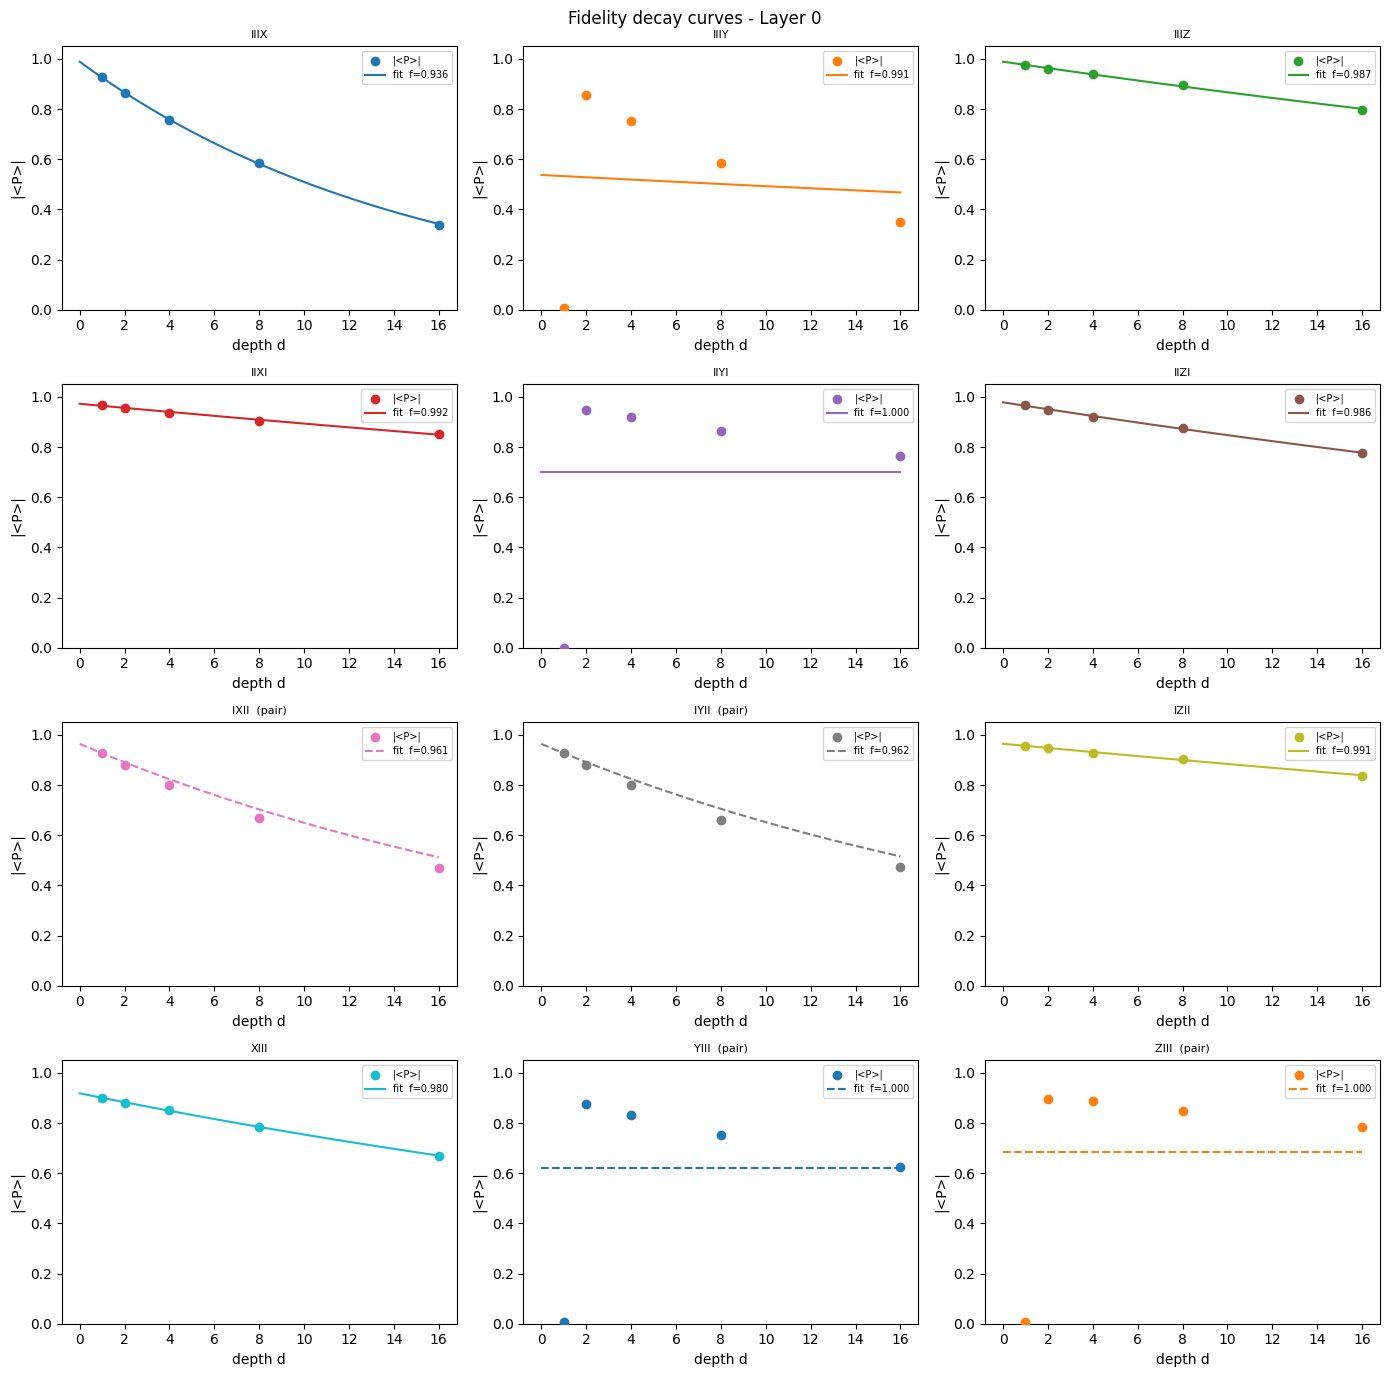

In [14]:
def plot_fidelity_curves(tomo_result, fidelities, spams, depths, deg_pairs,
                         layer_idx=0, max_terms=12):
    depths_arr = np.array(depths)
    x_fine     = np.linspace(0, max(depths), 200)
    partner = {p1: p2 for p1, p2 in deg_pairs}
    partner.update({p2: p1 for p1, p2 in deg_pairs})

    all_terms = sorted(fidelities.keys())
    w1 = [t for t in all_terms if sum(1 for c in t if c != 'I') == 1]
    w2 = [t for t in all_terms if t not in w1]
    show = (w1 + w2)[:max_terms]

    ncols = 3
    nrows = (len(show) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), squeeze=False)
    CMAP = plt.cm.tab10

    for idx, term in enumerate(show):
        ax  = axes[idx // ncols][idx % ncols]
        col = CMAP(idx % 10)
        ev  = np.array([tomo_result[d].get(term, np.nan) for d in depths])
        ax.scatter(depths_arr, np.abs(ev), color=col, zorder=3, label='|<P>|')

        spam = spams.get(term, 1.0)
        fid  = fidelities.get(term, 1.0)
        ls   = '--' if term in partner else '-'
        ax.plot(x_fine, spam * fid ** x_fine, color=col, ls=ls,
                label=f'fit  f={fid:.3f}')

        title = term
        if term in partner:
            title += f'  (pair)'
        ax.set_title(title, fontsize=8)
        ax.set_xlabel('depth d')
        ax.set_ylabel('|<P>|')
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7)

    for idx in range(len(show), nrows * ncols):
        axes[idx // ncols][idx % ncols].axis('off')

    fig.suptitle(f'Fidelity decay curves - Layer {layer_idx}', fontsize=12)
    plt.tight_layout()
    plt.show()


plot_fidelity_curves(
    tomo_results[0], layer_fidelities[0], layer_spams[0],
    DEPTHS_TOMO, layer_deg_pairs[0], layer_idx=0
)

## 7. NNLS Fit: Model Coefficients and Infidelity Bar Charts

From the Pauli fidelities we reconstruct the Lindblad **generator coefficients** $\lambda_k \ge 0$.

The fidelity-coefficient relation is
$$
-\tfrac{1}{2}\log f_a = \sum_k M_{ak}\,\lambda_k,
\quad
M_{ak} = \begin{cases}1 & P_a\text{ and }P_k\text{ anticommute}\\0&\text{otherwise}\end{cases}
$$

For degenerate terms the matrix is extended as $M = M_1 + M_2$,
where $M_2$ uses the Clifford-conjugated partner $P_a' = U^\dagger P_a U$
(or $P_a$ itself if the term is already lifted), following van den Berg et al.


Layer 0: max coeff = 0.01753
Layer 1: max coeff = 0.01727
Layer 2: max coeff = 0.00237
Layer 3: max coeff = 0.00248


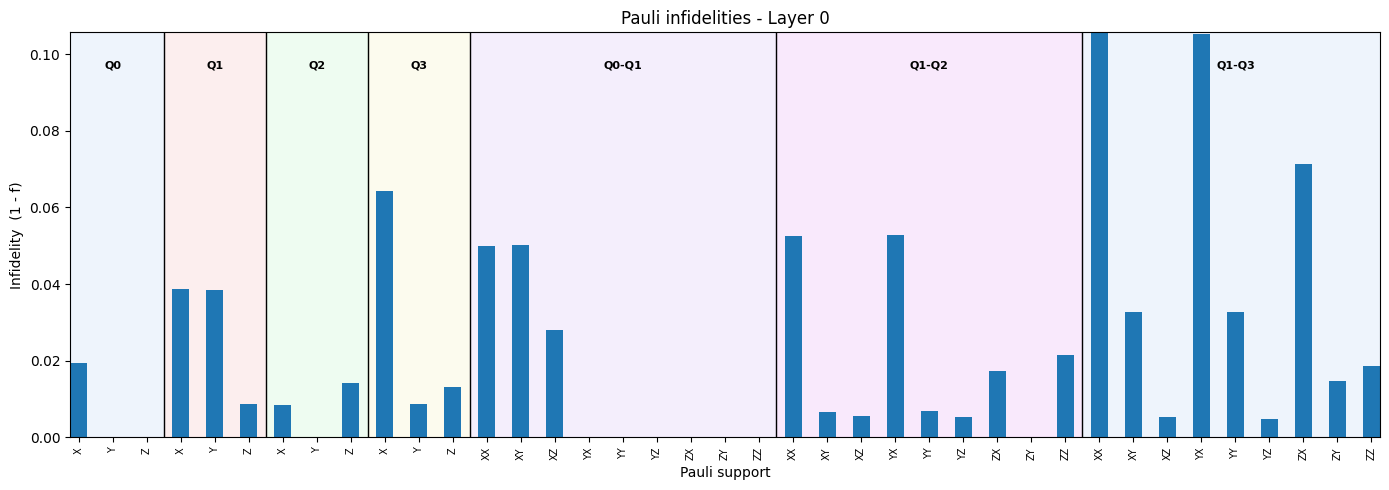

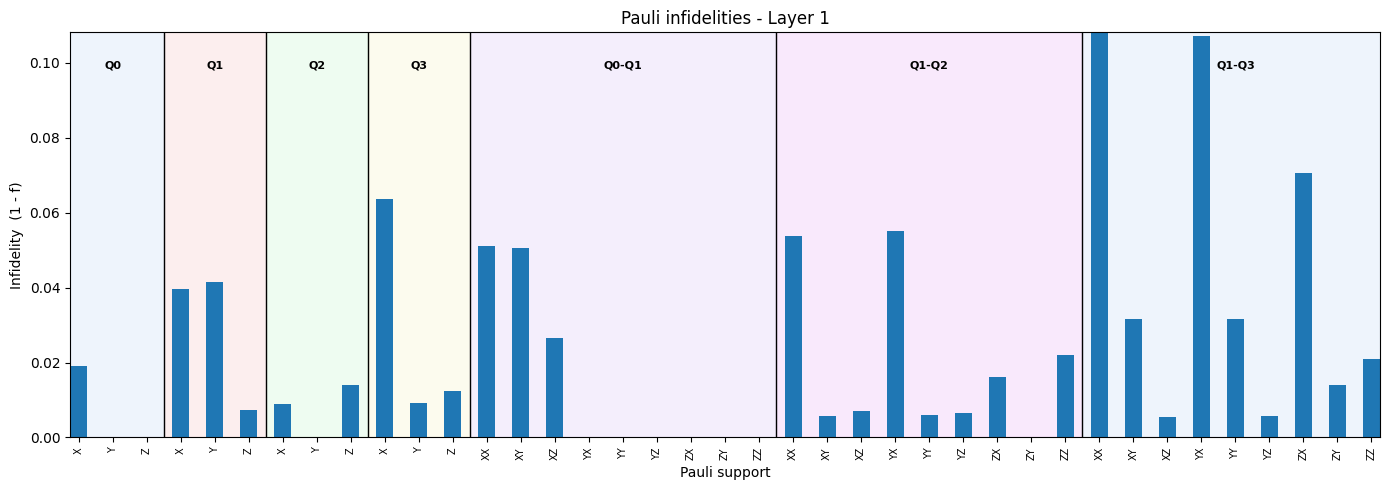

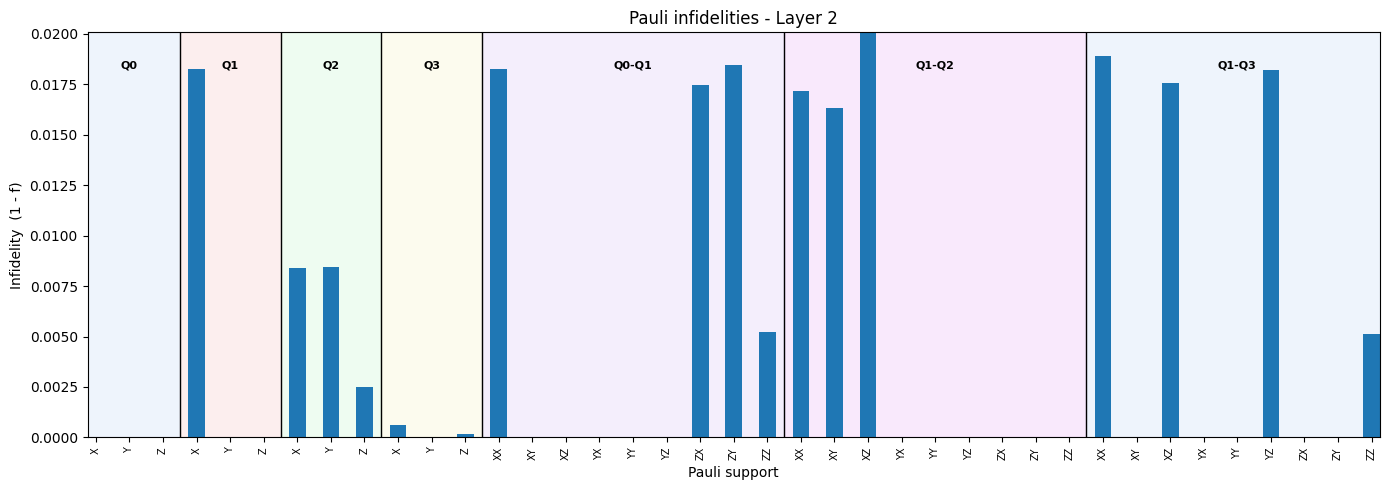

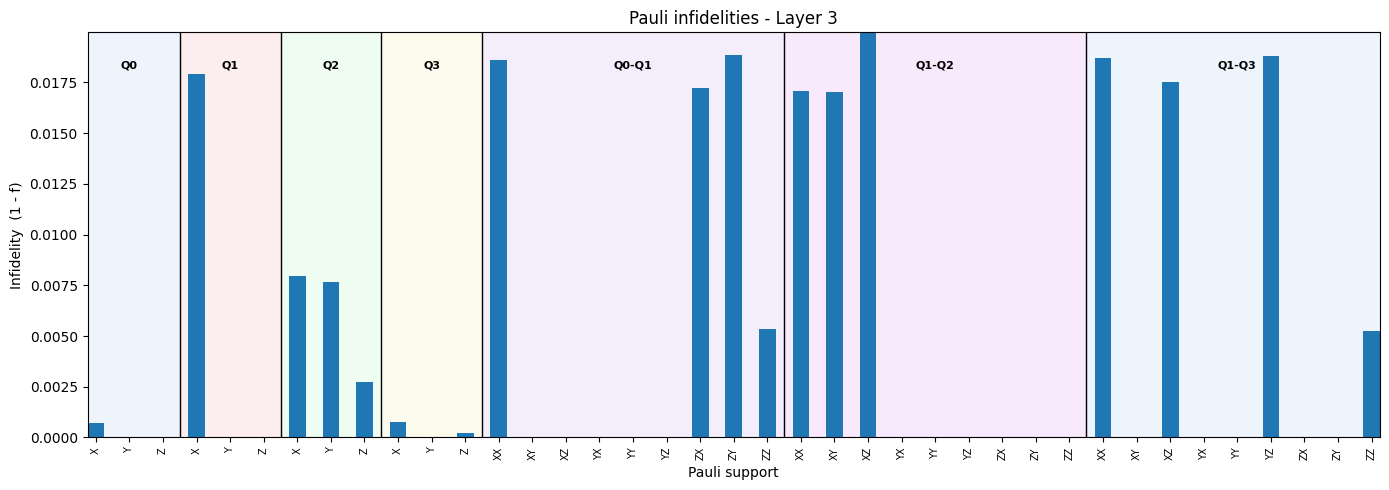

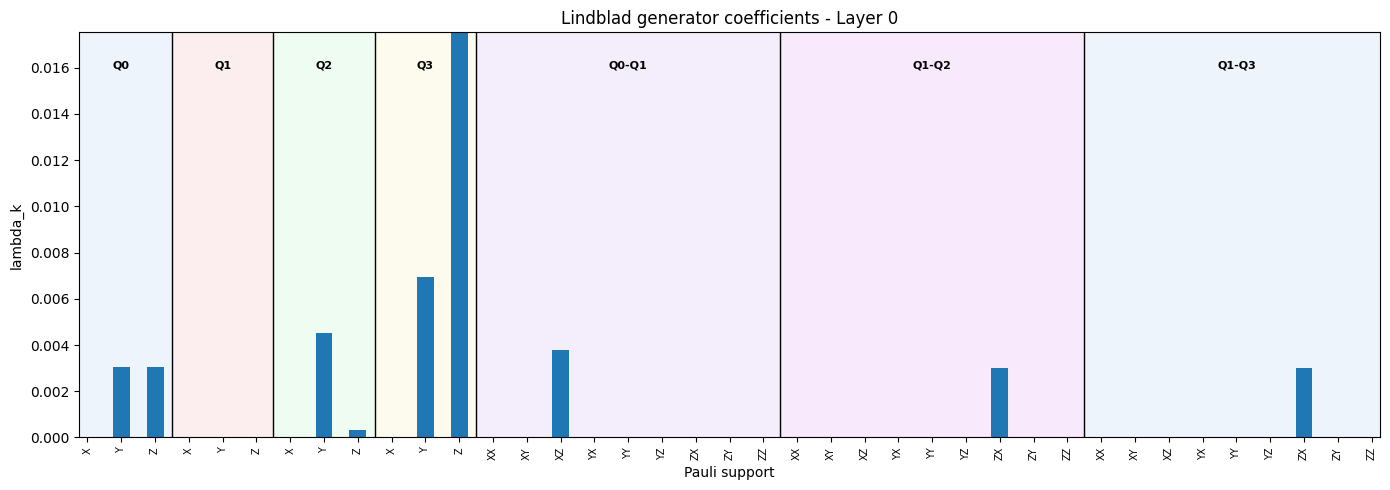

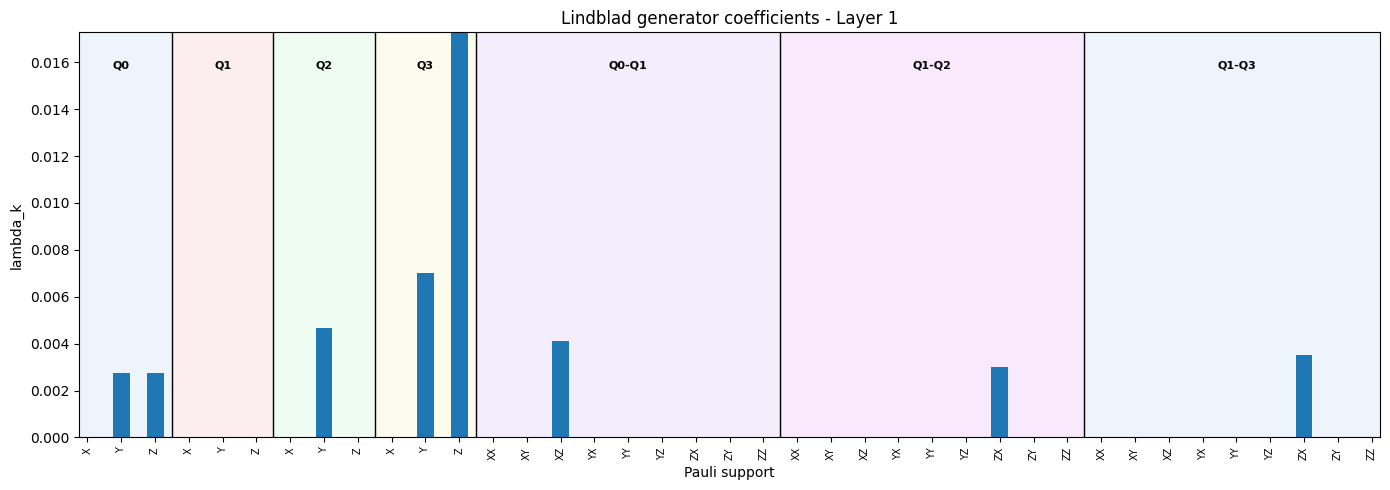

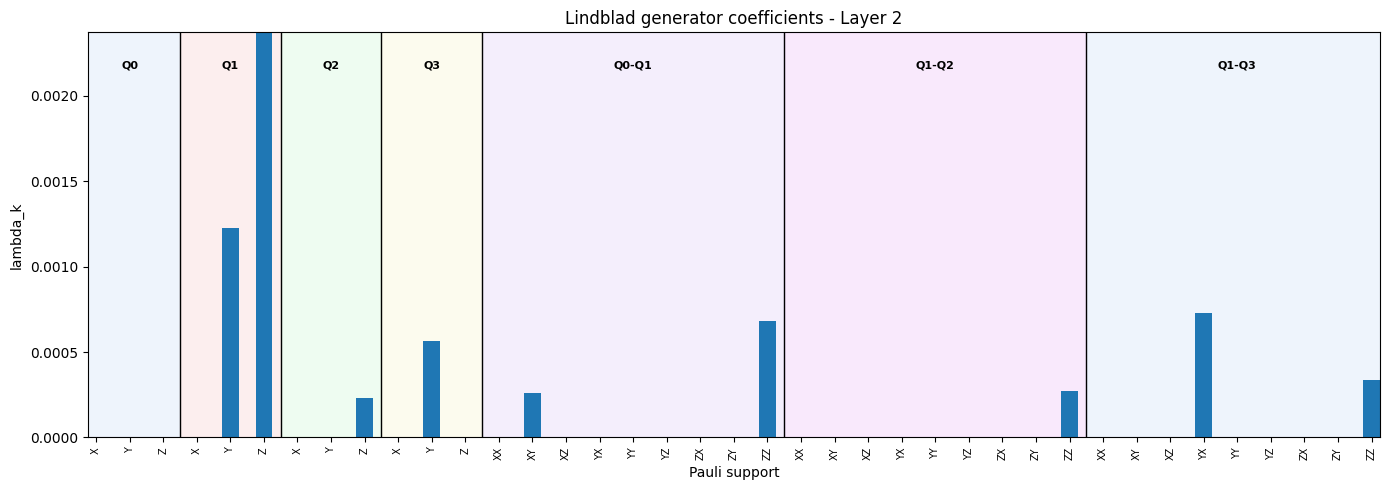

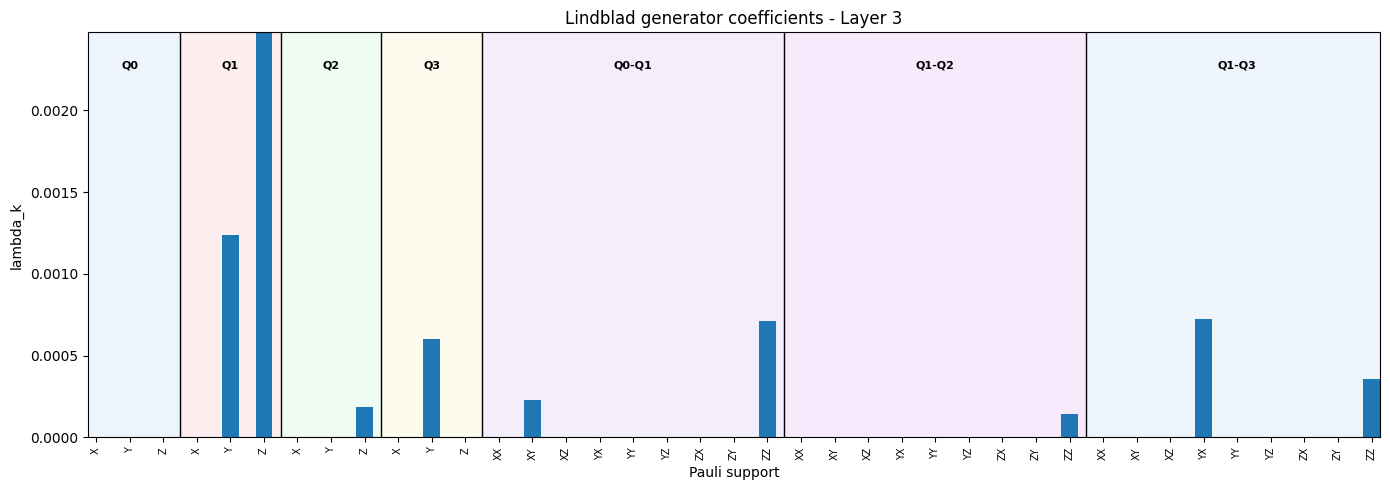

In [15]:
def pauli_anticommutes(p1, p2):
    ac = {('X','Y'),('Y','X'),('X','Z'),('Z','X'),('Y','Z'),('Z','Y')}
    return int(sum(1 for a, b in zip(p1, p2) if (a, b) in ac) % 2)


def nnls_fit_layer(model_terms, fidelities, layer, deg_pairs):
    # M = M1 + M2 where M2 uses Clifford-conjugated partners for non-degenerate terms.
    partner = {p1: p2 for p1, p2 in deg_pairs}
    partner.update({p2: p1 for p1, p2 in deg_pairs})

    F1 = list(model_terms)
    F2 = [t if t in partner else conjugate_pauli_2q(t, layer) for t in F1]

    n  = len(F1)
    M1 = np.array([[pauli_anticommutes(F1[b], F1[a]) for a in range(n)]
                   for b in range(n)], dtype=float)
    M2 = np.array([[pauli_anticommutes(F1[b], F2[a]) for a in range(n)]
                   for b in range(n)], dtype=float)
    M  = M1 + M2

    log_fids = np.array([
        -np.log(max(fidelities.get(t, 1.0), 1e-10))
        for t in F1
    ])

    if np.linalg.matrix_rank(M) < n:
        print('  Warning: M is rank-deficient.')

    coeffs, _ = scipy_nnls(M, log_fids)
    return dict(zip(F1, coeffs))


def plot_grouped_bars(model_terms, values, title, ylabel):
    palette = ['#d0e1f9','#f9d0d0','#d0f9d9','#f9f5d0','#e0d0f9','#f0c0f9']

    def support(t):
        return [i for i, p in enumerate(t) if p != 'I']
    def compact(t):
        return ''.join(p for p in t if p != 'I')

    groups = {}
    for t in model_terms:
        s = support(t)
        if len(s) == 1:
            key = (1, s[0])
        elif len(s) == 2:
            key = (2, tuple(sorted(s)))
        else:
            continue
        groups.setdefault(key, []).append(t)

    sorted_keys = sorted(groups)
    fig, ax = plt.subplots(figsize=(14, 5))
    pos, labels, vals, bgrects = [], [], [], []
    cur = 0
    for ci, key in enumerate(sorted_keys):
        color = palette[ci % len(palette)]
        grp   = sorted(groups[key], key=compact)
        lbl   = f'Q{key[1]}' if key[0] == 1 else f'Q{key[1][0]}-Q{key[1][1]}'
        bgrects.append((cur, len(grp), color, lbl))
        for t in grp:
            pos.append(cur); labels.append(compact(t))
            vals.append(values.get(t, 0.0)); cur += 1

    pos_arr = np.array(pos)
    ax.bar(pos_arr, vals, 0.5, color='tab:blue', zorder=2)
    ax.autoscale(tight=True)
    ymin, ymax = ax.get_ylim()
    for start, length, col, lbl in bgrects:
        ax.add_patch(mpatches.Rectangle(
            (start - 0.5, ymin), length, ymax - ymin,
            color=col, alpha=0.35, zorder=0
        ))
        ax.text(start + length / 2 - 0.5, ymax * 0.93, lbl,
                ha='center', va='top', fontsize=8, fontweight='bold')
    for x in [r[0] + r[1] - 0.5 for r in bgrects[:-1]]:
        ax.axvline(x, color='black', lw=1)
    ax.set_xticks(pos_arr)
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Pauli support')
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()


# fit coefficients for all layers
layer_coefficients = {}
for ell in range(len(layers)):
    layer_coefficients[ell] = nnls_fit_layer(
        model_terms, layer_fidelities[ell], layers[ell], layer_deg_pairs[ell]
    )
    maxc = max(layer_coefficients[ell].values())
    print(f'Layer {ell}: max coeff = {maxc:.5f}')

# infidelity bar plots
for ell in range(len(layers)):
    infids = {t: 1 - v for t, v in layer_fidelities[ell].items()}
    plot_grouped_bars(model_terms, infids,
                      title=f'Pauli infidelities - Layer {ell}',
                      ylabel='Infidelity  (1 - f)')

# model coefficient bar plots
for ell in range(len(layers)):
    plot_grouped_bars(model_terms, layer_coefficients[ell],
                      title=f'Lindblad generator coefficients - Layer {ell}',
                      ylabel='lambda_k')


## 8. Probabilistic Error Reduction (PER)

With the noise model in hand we apply **PER**: before each noisy layer we insert a Pauli
correction sampled from a quasi-probability decomposition (QPD) of the partial inverse
noise channel, and we reweight the measurement outcome by the sampling overhead.

### Quasi-probability decomposition

For a layer with Lindblad coefficients $\{\lambda_k\}$ and noise strength $\gamma$
($\gamma=0$: full cancellation, $\gamma=1$: no change):

- Apply $P_k$ with probability
  $p_k = \frac{1}{2}\bigl(1-e^{-2(1-\gamma)\lambda_k}\bigr)$,
  flipping the estimator sign.
- Overhead: $\Gamma = \prod_k e^{2(1-\gamma)\lambda_k}$.

The weighted estimator $\hat{O} = \Gamma\cdot(-1)^{\text{sign}}\cdot O_{\text{raw}}$
is an unbiased estimator of the noiseless expectation value.

### Zero-noise extrapolation

We run at $\gamma \in \{0.25, 0.5, 0.75, 1.0\}$ and fit a linear model
$E(\gamma)=a+b\gamma$; the intercept $a=E(0)$ estimates the ideal value.


In [16]:
def compute_per_probs(coefficients, noise_strength):
    # QPD probabilities and overhead for noise strength gamma in [0,1].
    # gamma=0: full cancellation, gamma=1: no change.
    probs    = {}
    overhead = 1.0
    for term, lam in coefficients.items():
        delta = (1.0 - noise_strength) * lam  # amount of noise to cancel
        p_k   = 0.5 * (1.0 - np.exp(-2.0 * delta))
        probs[term] = (p_k, 1)                # sign_bit=1: flip estimator sign
        if delta > 0:
            overhead *= np.exp(2.0 * delta)
    return probs, overhead


def sample_partial_inverse(probs, n_qubits):
    # Draw one Pauli correction from the QPD. Returns (pauli_str, sign_int).
    correction = 'I' * n_qubits
    sign = 0
    for term, (p_k, s_k) in probs.items():
        if random.random() < p_k:
            correction = pauli_multiply(correction, term)
            sign ^= s_k
    return correction, sign


import random

def build_per_circuit(qc_full, layers, all_layer_coeffs, noise_strength, meas_basis):
    """
    Builds a PER circuit: 1Q gates -> QPD correction + twirl -> 2Q gates -> resolve twirl.
    """
    n = qc_full.num_qubits
    qc = QuantumCircuit(n)
    tot_sign, tot_overhead = 0, 1.0

    for ell, layer in enumerate(layers):
        # (1) 1Q gates (ideal, not affected by noise)
        for inst in layer.data:
            if len(inst.qubits) == 1:
                qc.append(inst.operation, inst.qubits)

        # (2) Calculate QPD correction
        probs, overhead = compute_per_probs(all_layer_coeffs[ell], noise_strength)
        correction, sign = sample_partial_inverse(probs, n)
        tot_sign ^= sign
        tot_overhead *= overhead
        
        # (3) Sample a Pauli twirl for this layer
        twirl = "".join(random.choice(["I", "X", "Y", "Z"]) for _ in range(n))
        
        # (4) Combine correction AND twirl and apply BEFORE the noise
        # P_in = Twirl * Correction (Phase does not matter since apply_pauli_string only applies X, Y, Z)
        P_in = pauli_multiply(twirl, correction)
        apply_pauli_string(qc, P_in)

        # (5) 2Q Clifford gates (This is where the noise occurs on the real backend/simulator!)
        for inst in layer.data:
            if len(inst.qubits) == 2:
                qc.append(inst.operation, inst.qubits)
                
        # (6) Conjugate twirl and apply AFTER the 2Q layer to resolve it
        P_out = conjugate_pauli_2q(twirl, layer)
        apply_pauli_string(qc, P_out)

    # Measurement basis rotation
    for q, b in enumerate(meas_basis):
        if b == 'X':
            qc.h(q)
        elif b == 'Y':
            qc.sdg(q)
            qc.h(q)

    qc.measure_all()
    return qc, tot_sign, tot_overhead

def run_per(qc_full, layers, all_layer_coeffs, noise_strengths,
            expectations, n_samples, sampler):
    per_groups     = group_paulis(expectations)
    per_meas_bases = determine_measurement_bases(per_groups)

    all_circuits, all_meta = [], []
    for lmbda in noise_strengths:
        for b_idx, basis in enumerate(per_meas_bases):
            for _ in range(n_samples):
                qc_p, sign, overhead = build_per_circuit(
                    qc_full, layers, all_layer_coeffs, lmbda, basis
                )
                all_circuits.append(qc_p)
                all_meta.append((lmbda, b_idx, sign, overhead))

    result      = sampler.run(all_circuits).result()
    counts_list = [r.data.meas.get_counts() for r in result]

    per_data = {t: {lmbda: [] for lmbda in noise_strengths} for t in expectations}
    for (lmbda, b_idx, sign, overhead), counts in zip(all_meta, counts_list):
        for term in per_groups[b_idx]:
            if term in per_data:
                ev = get_expectation(Pauli(term), counts)
                per_data[term][lmbda].append(ev * overhead * ((-1) ** sign))
    return per_data


def extrapolate_per(per_data, noise_strengths):
    # Linear fit E(gamma) = a + b*gamma -> intercept a = E(0) is the mitigated value.
    strengths = sorted(noise_strengths)
    mitigated = {}
    for term, sd in per_data.items():
        means = [np.mean(sd[s]) for s in strengths]
        b, a  = np.polyfit(strengths, means, 1) if len(strengths) >= 2 else (0, means[0])
        mitigated[term] = a
    return mitigated


Running PER: 50 samples x 4 strengths ...
PER done.
Exact energy (diagonalisation): -8.6660
Ideal  (Statevector):           -8.4464
Noisy  (no mitigation):         -7.5200   error = 1.1460
PER mitigated:                  -8.4039   error = 0.2620


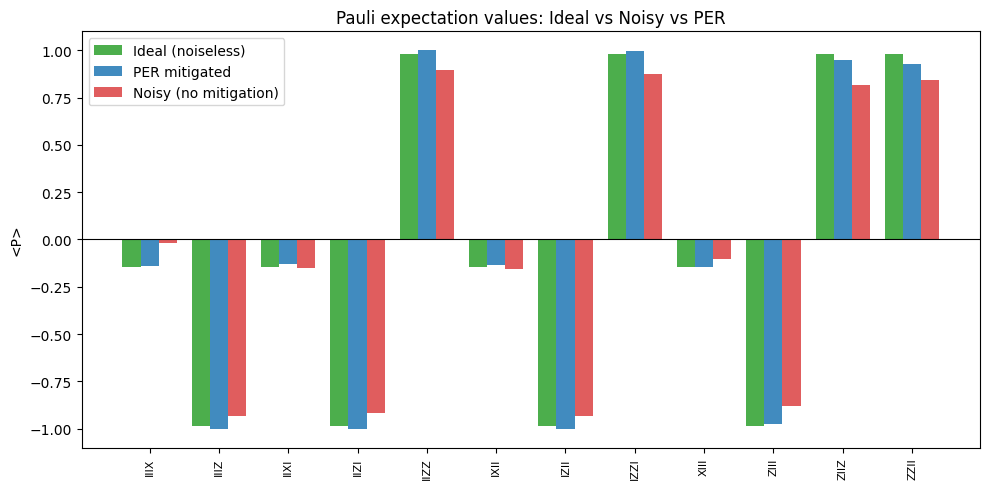

In [19]:
NOISE_STRENGTHS = [0.25, 0.50, 0.75, 1.0]
N_PER_SAMPLES   = 50

per_expectations = list(set(pauli_list))
print(f'Running PER: {N_PER_SAMPLES} samples x {len(NOISE_STRENGTHS)} strengths ...')

per_data = run_per(
    qc_bound, layers, layer_coefficients,
    NOISE_STRENGTHS, per_expectations, N_PER_SAMPLES, sampler
)

# Hole die extrapolierten Werte
mitigated_expvals = extrapolate_per(per_data, NOISE_STRENGTHS)

# NEU: Clippe alle Werte hart auf das physikalische Intervall [-1, 1]
for term in mitigated_expvals:
    mitigated_expvals[term] = float(np.clip(mitigated_expvals[term], -1.0, 1.0))

print('PER done.')


# Noisy (unmitigated) expectation values
noisy_groups  = group_paulis(per_expectations)
noisy_bases   = determine_measurement_bases(noisy_groups)
noisy_circs   = []
for basis in noisy_bases:
    qc_n = qc_bound.copy()
    for q, b in enumerate(basis):
        if b == 'X': qc_n.h(q)
        elif b == 'Y': qc_n.sdg(q); qc_n.h(q)
    qc_n.measure_all()
    noisy_circs.append(qc_n)

noisy_res    = sampler.run(noisy_circs).result()
noisy_counts = [r.data.meas.get_counts() for r in noisy_res]
noisy_expvals = {}
for b_idx, counts in enumerate(noisy_counts):
    for term in noisy_groups[b_idx]:
        if term in per_expectations:
            noisy_expvals[term] = get_expectation(Pauli(term), counts)


# Ideal expectation values via Statevector
ideal_expvals = {}
psi_ideal = Statevector.from_instruction(qc_bound)
for term in per_expectations:
    op = SparsePauliOp.from_list([(term, 1.0)])
    ideal_expvals[term] = float(np.real(psi_ideal.expectation_value(op)))


# Energy comparison
ham_coeffs = {p.to_label(): float(np.real(c))
              for p, c in zip(Hamiltonian.paulis, Hamiltonian.coeffs)}

def compute_energy(expvals):
    return sum(ham_coeffs.get(t, 0.0) * expvals.get(t, 0.0) for t in ham_coeffs)

E_exact = float(exact_energy)
E_ideal = compute_energy(ideal_expvals)
E_noisy = compute_energy(noisy_expvals)
E_per   = compute_energy(mitigated_expvals)

print(f'Exact energy (diagonalisation): {E_exact:.4f}')
print(f'Ideal  (Statevector):           {E_ideal:.4f}')
print(f'Noisy  (no mitigation):         {E_noisy:.4f}   error = {abs(E_noisy - E_exact):.4f}')
print(f'PER mitigated:                  {E_per:.4f}   error = {abs(E_per  - E_exact):.4f}')


# Bar chart: expectation values per Pauli term
terms_sorted = sorted(per_expectations)
x = np.arange(len(terms_sorted))
w = 0.26

fig, ax = plt.subplots(figsize=(max(10, len(terms_sorted) * 0.55), 5))
ax.bar(x - w, [ideal_expvals.get(t, 0) for t in terms_sorted],
       w, label='Ideal (noiseless)', color='tab:green', alpha=0.85)
ax.bar(x, [mitigated_expvals.get(t, 0) for t in terms_sorted],
       w, label='PER mitigated', color='tab:blue', alpha=0.85)
ax.bar(x + w,     [noisy_expvals.get(t, 0) for t in terms_sorted],
       w, label='Noisy (no mitigation)', color='tab:red', alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(terms_sorted, rotation=90, fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Pauli expectation values: Ideal vs Noisy vs PER')
ax.set_ylabel('<P>')
ax.legend()
plt.tight_layout()
plt.show()

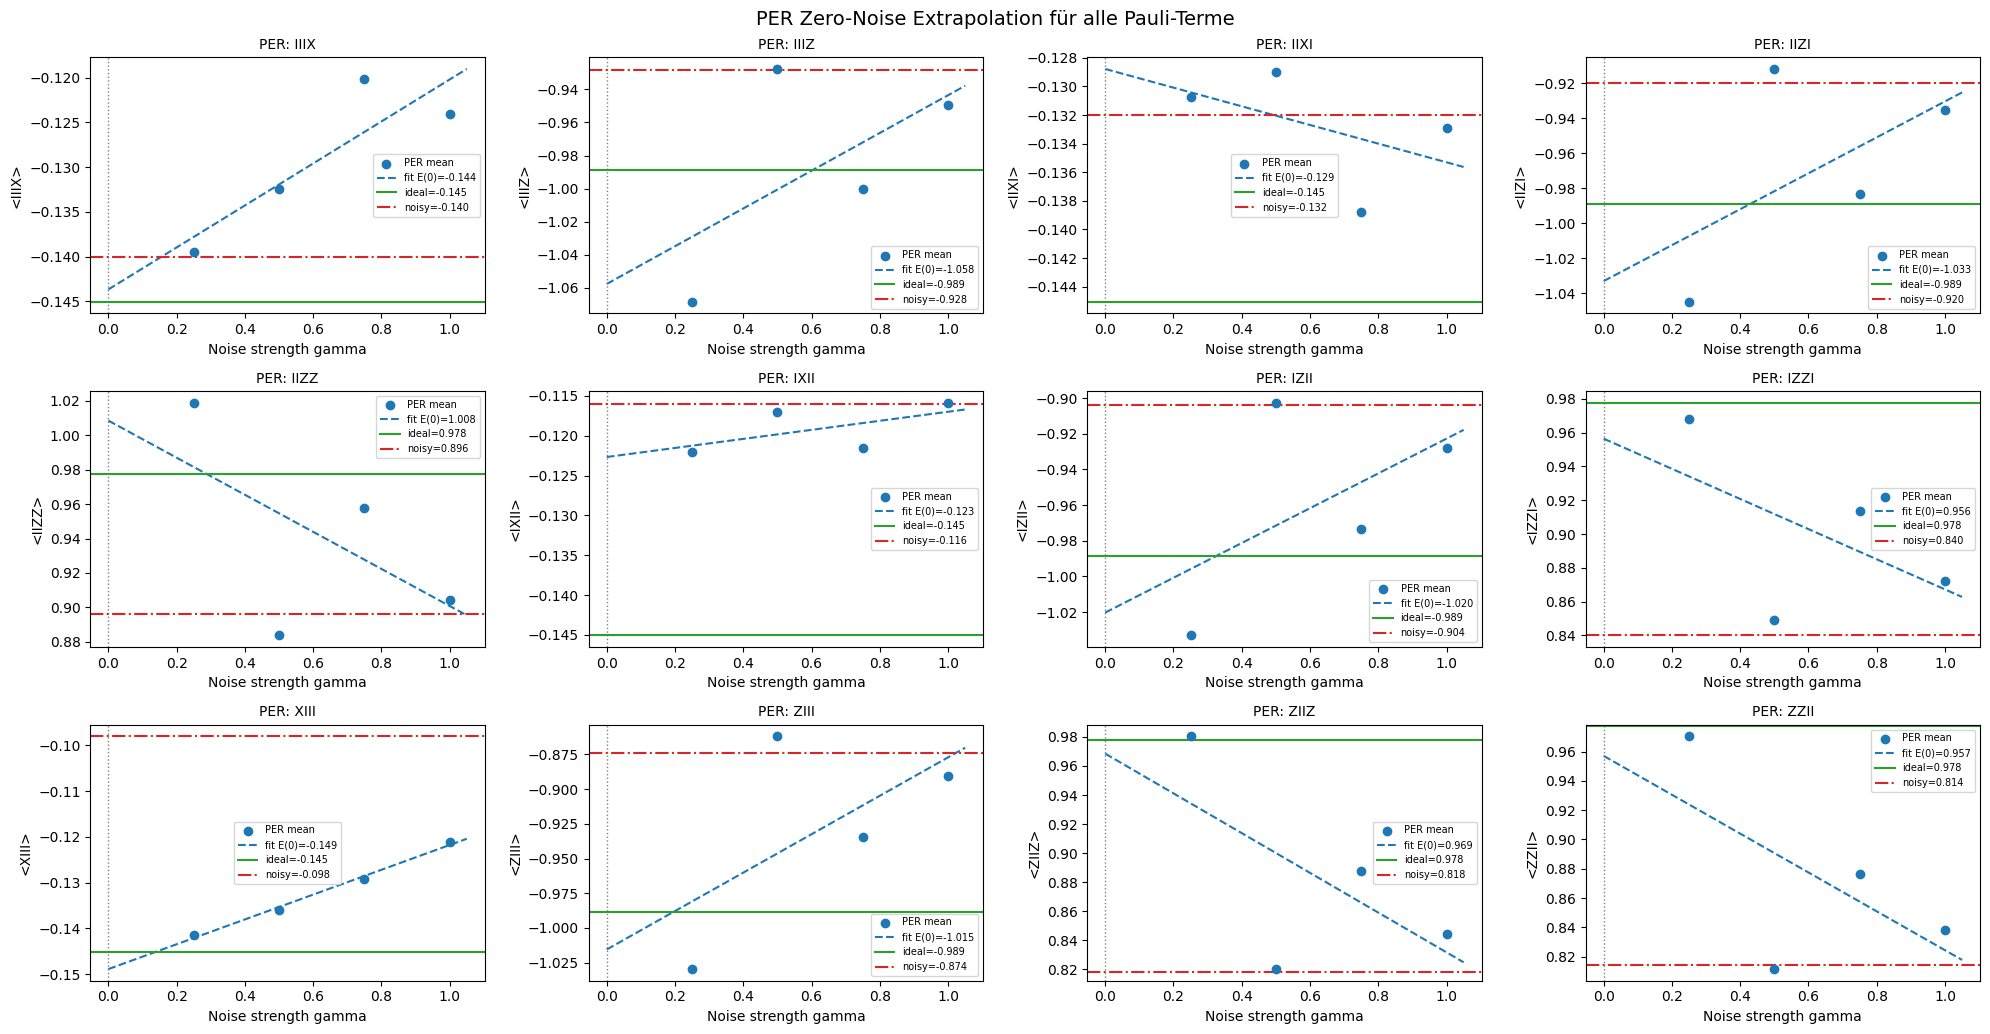

In [18]:
import numpy as np
import matplotlib.pyplot as plt


terms_sorted = sorted(per_expectations)
num_terms = len(terms_sorted)

ncols = 4
nrows = (num_terms + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.5 * nrows), squeeze=False)

strengths_s = sorted(NOISE_STRENGTHS)
x_fit = np.linspace(0, 1.05, 200)

for idx, term in enumerate(terms_sorted):
    ax = axes[idx // ncols][idx % ncols]
    
    means_s = [np.mean(per_data[term][s]) for s in strengths_s]
    
    p_lin = np.polyfit(strengths_s, means_s, 1)
    
    ax.scatter(strengths_s, means_s, color='tab:blue', zorder=3, label='PER mean')
    ax.plot(x_fit, np.polyval(p_lin, x_fit), 'tab:blue', ls='--', 
            label=f'fit E(0)={p_lin[1]:.3f}')
    
    ax.axvline(0, color='gray', ls=':', lw=1)
    ax.axhline(ideal_expvals.get(term, 0), color='tab:green', ls='-',
               label=f'ideal={ideal_expvals.get(term,0):.3f}')
    ax.axhline(noisy_expvals.get(term, 0), color='tab:red', ls='-.',
               label=f'noisy={noisy_expvals.get(term,0):.3f}')
    
    ax.set_xlabel('Noise strength gamma')
    ax.set_ylabel(f'<{term}>')
    ax.set_title(f'PER: {term}', fontsize=10)
    ax.legend(fontsize=7)

for idx in range(num_terms, nrows * ncols):
    axes[idx // ncols][idx % ncols].axis('off')

fig.suptitle('PER Zero-Noise Extrapolation für alle Pauli-Terme', fontsize=14)
plt.tight_layout()
plt.show()